In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel("clean_data.xlsx")

In [5]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Tenure_Months,Subscription_Type,Monthly_Charges,Total_Charges,Contract_Type,Payment_Method,Internet_Service,Tech_Support,Senior_Citizen,Dependents,Churn,Last_Interaction_Date
0,C1000,Abhishek Jaiswal,Female,35,Maharashtra,Pune,58,Basic,1614.26,93273.08,One Year,UPI,Fiber,Yes,No,Yes,No,2025-10-12
1,C1001,Rohit Kumar,Male,46,Delhi,Noida,36,Premium,429.60,15858.60,Two Year,Cash,DSL,Yes,Yes,No,No,2026-03-05
2,C1002,Pooja Singh,Female,42,UP,Kanpur,13,Basic,555.03,6869.39,Month-to-Month,Debit Card,5G,No,No,No,Yes,2026-02-20
3,C1003,Unknown,Male,59,Karnataka,Bengaluru,55,Standard,1285.78,101349.10,Two Year,UPI,5G,No,No,Yes,No,2026-06-07
4,C1004,Mohit Arora,Male,26,Gujarat,Ahmedabad,6,Premium,314.02,1926.12,One Year,Debit Card,Cable,Yes,No,No,No,2026-04-02


In [6]:
df.shape

(531, 18)

In [7]:
df.isna().sum()

Customer_ID              0
Customer_Name            0
Gender                   0
Age                      0
State                    0
City                     0
Tenure_Months            0
Subscription_Type        0
Monthly_Charges          0
Total_Charges            0
Contract_Type            0
Payment_Method           0
Internet_Service         0
Tech_Support             0
Senior_Citizen           0
Dependents               0
Churn                    0
Last_Interaction_Date    3
dtype: int64

In [8]:
# how many customer churn and what is the percentage of it 

In [9]:
df["Churn"].value_counts()

Churn
No     404
Yes    127
Name: count, dtype: int64

In [10]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     76.082863
Yes    23.917137
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Customer_churn_count')

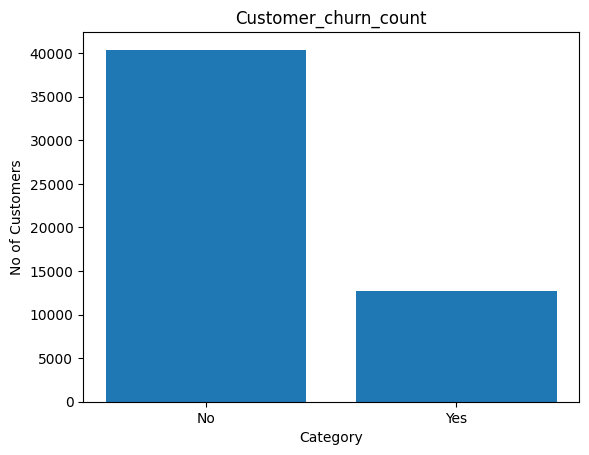

In [11]:
count = df["Churn"].value_counts() * 100
no_count = count["No"]
yes_count = count["Yes"]

category = ["No", "Yes"]
value = [no_count, yes_count]
plt.bar(category, value)
plt.xlabel("Category")
plt.ylabel("No of Customers")
plt.title("Customer_churn_count")

In [12]:
# For each contract type, how many customers churned and what is the percentage of it?

In [13]:
df["Contract_Type"].groupby(df["Churn"]).value_counts()

Churn  Contract_Type 
No     Month-to-Month    154
       One Year          130
       Two Year          120
Yes    One Year           44
       Two Year           42
       Month-to-Month     41
Name: count, dtype: int64

In [14]:
total_customer = df["Churn"].groupby(df["Contract_Type"]).count()

In [15]:
churn_customer = df[df["Churn"] == "Yes"].groupby("Contract_Type")["Customer_ID"].count()

In [16]:
churn_rate = churn_customer / total_customer * 100

In [17]:
churn_rate

Contract_Type
Month-to-Month    21.025641
One Year          25.287356
Two Year          25.925926
dtype: float64

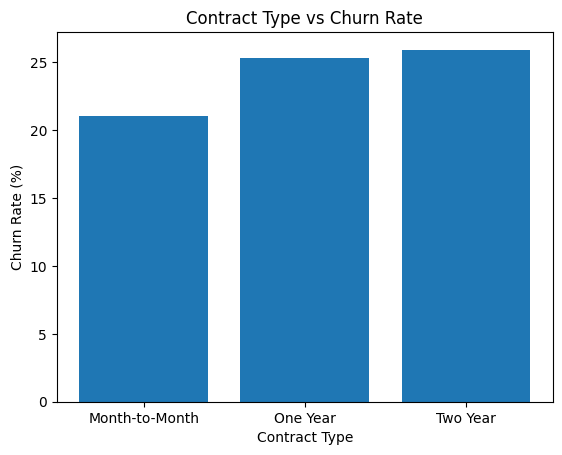

In [18]:
plt.bar(churn_rate.index, churn_rate.values)

plt.title("Contract Type vs Churn Rate")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [19]:
# 1. Which contract type has the highest churn rate?
#    Two Years has the highest churn rate among the contract types.


# 2. Is it correct to say that contract type "causes" churn based only on this chart? Why or why not?  
#    no , we cant say that, because there are many other factors on which churn depends



In [20]:
# Do customers who churn have different tenure compared with customers who don't churn?

In [21]:
average_Tenure_Months = df["Tenure_Months"].groupby(df["Churn"]).mean()

In [22]:
average_Tenure_Months

Churn
No     37.460396
Yes    33.503937
Name: Tenure_Months, dtype: float64

In [23]:
# Customers who churned had a lower average tenure than customers who did not churn. This suggests that tenure may be associated with churn, but further analysis is needed to understand the relationship.

In [24]:
average_Tenure_Months_median = df["Tenure_Months"].groupby(df["Churn"]).median()

In [25]:
average_Tenure_Months_median

Churn
No     39.0
Yes    32.0
Name: Tenure_Months, dtype: float64

In [26]:
# Churned customers have lower average and median tenure than non-churned customers. This suggests that customers with shorter tenure may be more likely to churn, although this analysis alone does not establish causation.

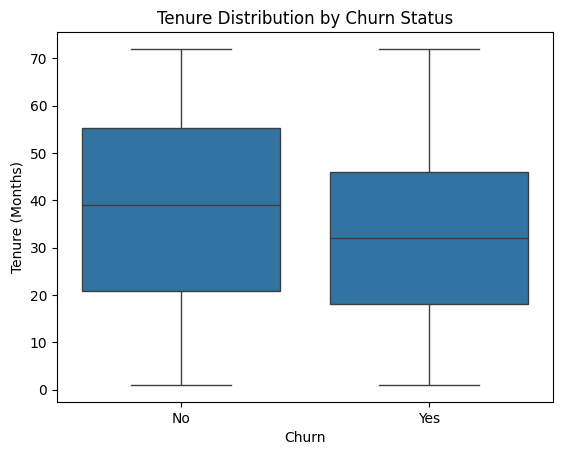

In [27]:
sns.boxplot(data=df, x='Churn', y='Tenure_Months')

plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

In [28]:
# The box plot shows that churned customers generally have lower tenure than non-churned customers. The median tenure is also lower for churned customers, supporting the pattern found from the mean and median calculations. However, there is considerable overlap between the two groups, so tenure alone cannot explain customer churn.

In [29]:
# Does Monthly Charges differ by Churn?

In [30]:
df["Monthly_Charges"].groupby(df["Churn"]).mean()

Churn
No     1360.792129
Yes    1353.438543
Name: Monthly_Charges, dtype: float64

In [31]:
df["Monthly_Charges"].groupby(df["Churn"]).median()

Churn
No     1301.34
Yes    1295.83
Name: Monthly_Charges, dtype: float64

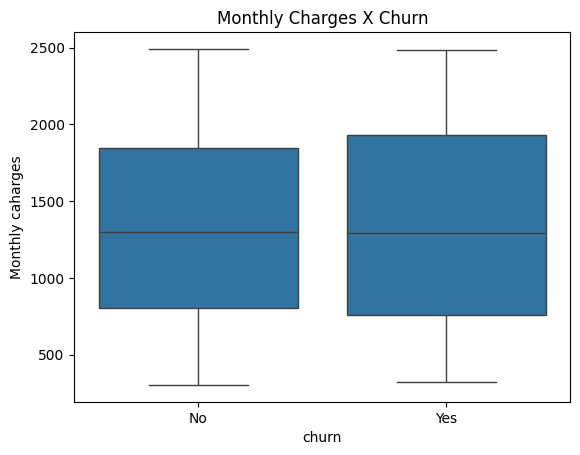

In [32]:
sns.boxplot(data=df, x='Churn', y = 'Monthly_Charges')

plt.title("Monthly Charges X Churn")
plt.xlabel("churn")
plt.ylabel("Monthly caharges")
plt.show()

In [33]:
# Monthly charges show only a weak or no obvious relationship with churn in this dataset. The average monthly charges are almost identical for churned and non-churned customers, and the box plots show substantial overlap between the two groups.

In [34]:
# Does Subscription Type have different churn rates?

In [35]:
total_customer_count = df["Churn"].groupby(df["Subscription_Type"]).count()

In [36]:
subscription_churned_count = df[df["Churn"] == "Yes"].groupby("Subscription_Type")["Subscription_Type"].count()

In [37]:
subscription_churned_count

Subscription_Type
Basic       30
Premium     49
Standard    48
Name: Subscription_Type, dtype: int64

In [38]:
churn_rate = subscription_churned_count / total_customer_count * 100

In [39]:
churn_rate

Subscription_Type
Basic       17.647059
Premium     25.520833
Standard    28.402367
dtype: float64

Text(0, 0.5, 'Churn_Rate')

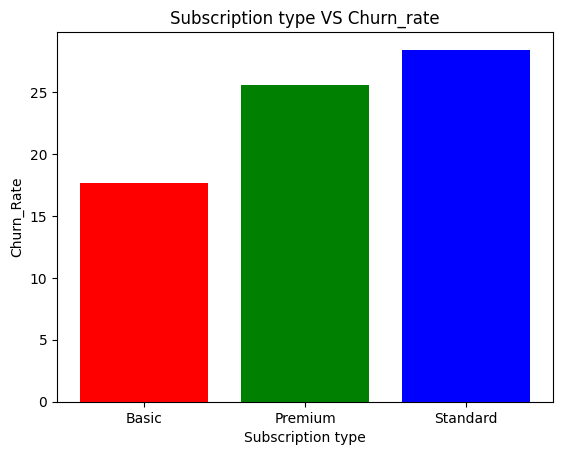

In [40]:
plt.bar(churn_rate.index, churn_rate.values, color = ["red", "green","blue"])
plt.title("Subscription type VS Churn_rate" )
plt.xlabel("Subscription type")
plt.ylabel("Churn_Rate")

In [41]:
# Standard subscription has the highest churn rate, while Basic has the lowest

In [42]:
# Do customers using different Internet Service types have different churn rates?

In [43]:
total_customer_count_services = df["Churn"].groupby(df["Internet_Service"]).count()

In [44]:
total_customer_count_services

Internet_Service
5G       126
Cable    132
DSL      129
Fiber    144
Name: Churn, dtype: int64

In [45]:
internet_churn_customer = df[df["Churn"] == "Yes"].groupby("Internet_Service")["Internet_Service"].count()

In [46]:
internet_churn_customer

Internet_Service
5G       30
Cable    38
DSL      25
Fiber    34
Name: Internet_Service, dtype: int64

In [47]:
internet_churn_rate = internet_churn_customer / total_customer_count_services * 100

In [48]:
internet_churn_rate

Internet_Service
5G       23.809524
Cable    28.787879
DSL      19.379845
Fiber    23.611111
dtype: float64

Text(0.5, 0, 'services')

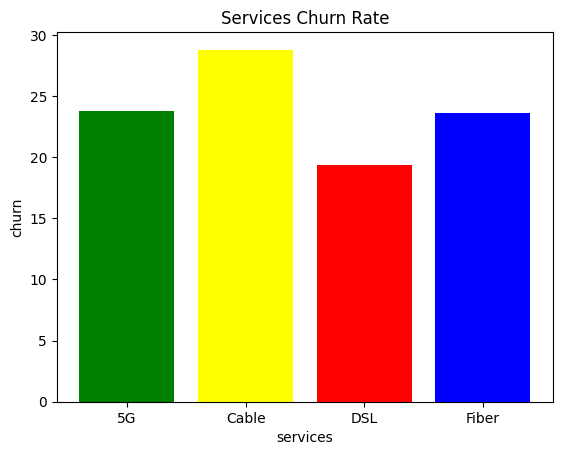

In [49]:
plt.bar(internet_churn_rate.index, internet_churn_rate.values, color = ["green", "yellow", "red", "blue"])
plt.title("Services Churn Rate")
plt.ylabel("churn")
plt.xlabel("services")

In [50]:
# Does Tech Support relate to Churn?

In [51]:
total_customer_tech_support = df["Churn"].groupby(df["Tech_Support"]).count()

In [52]:
total_customer_tech_support

Tech_Support
No     273
Yes    258
Name: Churn, dtype: int64

In [53]:
tch_support_churn_customer = df[df["Churn"] == "Yes"].groupby("Tech_Support")["Tech_Support"].count()

In [54]:
tch_support_churn_customer

Tech_Support
No     64
Yes    63
Name: Tech_Support, dtype: int64

In [55]:
tech_support_churn_rate = tch_support_churn_customer / total_customer_tech_support * 100
tech_support_churn_rate

Tech_Support
No     23.443223
Yes    24.418605
dtype: float64

Text(0, 0.5, 'Churn')

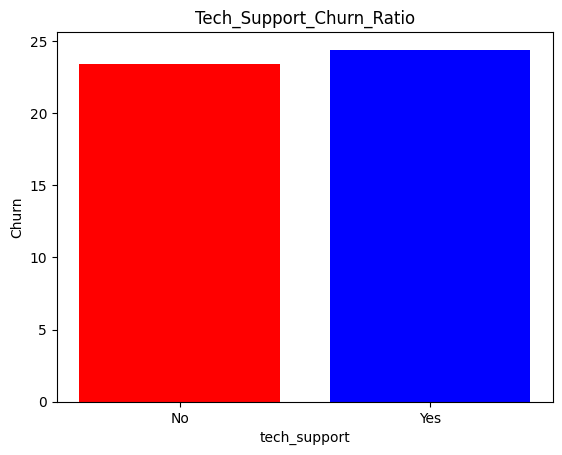

In [56]:
plt.bar(tech_support_churn_rate.index, tech_support_churn_rate.values, color = ["red", "blue"])
plt.title("Tech_Support_Churn_Ratio")
plt.xlabel("tech_support")
plt.ylabel("Churn")

In [57]:
# The churn rates for customers with and without tech support are very similar. Therefore, Tech Support does not show an obvious strong relationship with churn in this dataset.

In [58]:
# Does the payment method have different churn rates?

In [60]:
total_customer_payment_method = df["Churn"].groupby(df["Payment_Method"]).count()
total_customer_payment_method

Payment_Method
Cash           103
Credit Card     99
Debit Card     124
Net Banking     97
UPI            108
Name: Churn, dtype: int64

In [62]:
payment_method_churn_customer = df[df["Churn"] == "Yes"].groupby("Payment_Method")["Payment_Method"].count()
payment_method_churn_customer

Payment_Method
Cash           18
Credit Card    24
Debit Card     36
Net Banking    20
UPI            29
Name: Payment_Method, dtype: int64

In [63]:
churn_rate_payment_method = payment_method_churn_customer / total_customer_payment_method * 100
churn_rate_payment_method

Payment_Method
Cash           17.475728
Credit Card    24.242424
Debit Card     29.032258
Net Banking    20.618557
UPI            26.851852
dtype: float64

Text(0.5, 1.0, 'churn_rate_payment_method')

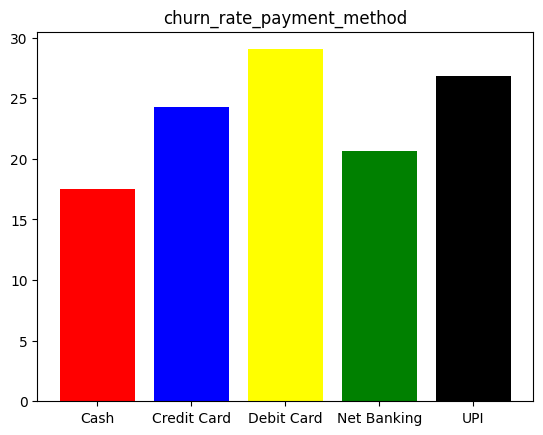

In [65]:
plt.bar(churn_rate_payment_method.index, churn_rate_payment_method.values, color = ["Red", "Blue", "Yellow", "green", "black"])
plt.title("churn_rate_payment_method")

In [66]:
# Debit Card customers have the highest observed churn rate at 29.03%, while Cash customers have the lowest at 17.48%. This shows a noticeable difference in churn rates across payment methods, suggesting that payment method may be associated with churn in this dataset. However, this analysis does not establish that the payment method causes churn.

In [67]:
# Do Senior Citizens have a different churn rate compared with non-senior customers?

In [68]:
total_customer_citizen = df["Churn"].groupby(df["Senior_Citizen"]).count()
total_customer_citizen

Senior_Citizen
No     428
Yes    103
Name: Churn, dtype: int64

In [69]:
citizen_churn_customer = df[df["Churn"] == "Yes"].groupby("Senior_Citizen")["Senior_Citizen"].count()
citizen_churn_customer

Senior_Citizen
No     105
Yes     22
Name: Senior_Citizen, dtype: int64

In [70]:
citizen_churn_ratio = citizen_churn_customer / total_customer_citizen * 100
citizen_churn_ratio

Senior_Citizen
No     24.532710
Yes    21.359223
dtype: float64

Text(0, 0.5, 'Churn Rate (%)')

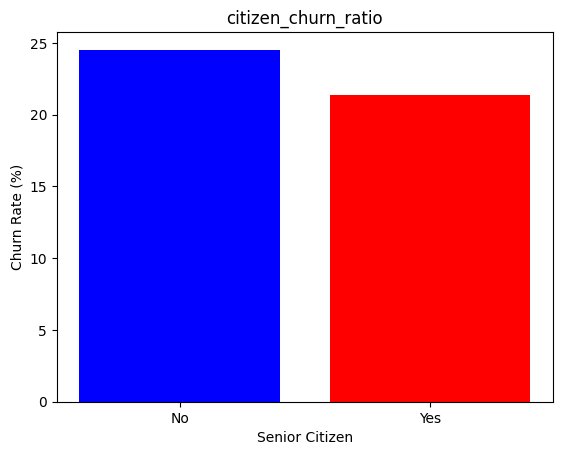

In [73]:
plt.bar(citizen_churn_ratio.index, citizen_churn_ratio.values, color = ["blue", "red"])
plt.title("citizen_churn_ratio")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

In [72]:
# Senior citizens have a slightly lower observed churn rate than non-senior customers (21.36% vs 24.53%). The difference is relatively small, so Senior Citizen status does not appear to have a strong relationship with churn in this dataset.

In [74]:
# Do customers with dependents have a different churn rate from customers without dependents?

In [76]:
dependent_total_customer = df["Churn"].groupby(df["Dependents"]).count()
dependent_total_customer

Dependents
No     270
Yes    261
Name: Churn, dtype: int64

In [77]:
dependent_churn_customer = df[df["Churn"] == "Yes"].groupby("Dependents")["Dependents"].count()
dependent_churn_customer

Dependents
No     58
Yes    69
Name: Dependents, dtype: int64

In [78]:
dependent_churn_ratio = dependent_churn_customer / dependent_total_customer * 100
dependent_churn_ratio

Dependents
No     21.481481
Yes    26.436782
dtype: float64

Text(0, 0.5, 'churn')

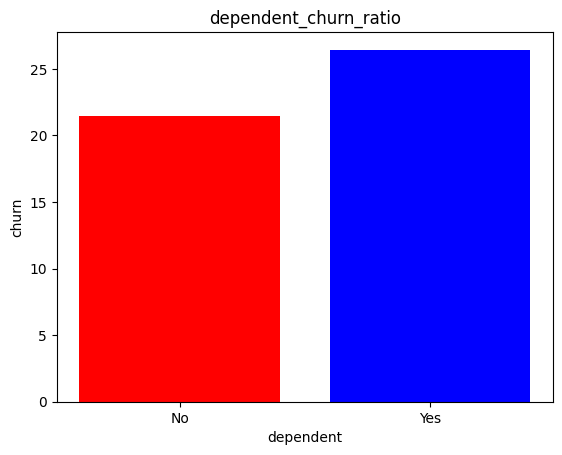

In [81]:
plt.bar(dependent_churn_ratio.index, dependent_churn_ratio.values, color = ["red", "blue"])
plt.title("dependent_churn_ratio")
plt.xlabel("dependent")
plt.ylabel("churn")

In [82]:
# Total Charges vs Churn

In [84]:
total_charges_total_customer = df["Total_Charges"].groupby(df["Churn"]).mean()
total_charges_total_customer

Churn
No     51604.658045
Yes    48614.595591
Name: Total_Charges, dtype: float64

In [85]:
total_charges_total_customer = df["Total_Charges"].groupby(df["Churn"]).median()
total_charges_total_customer

Churn
No     42180.61
Yes    33960.60
Name: Total_Charges, dtype: float64

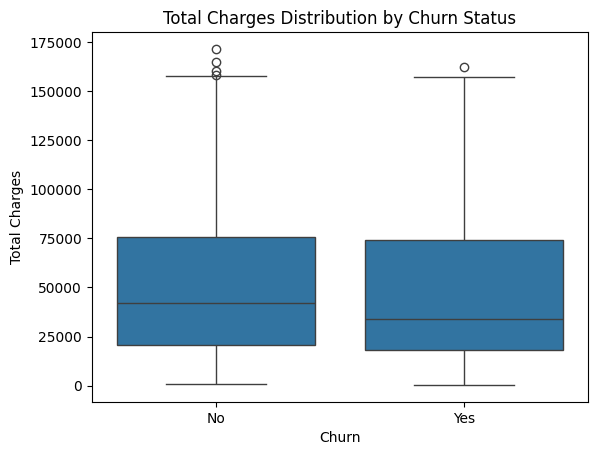

In [86]:
sns.boxplot(data=df, x="Churn", y="Total_Charges")

plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

In [87]:
# Churned customers have lower mean and median total charges than non-churned customers. The difference is more noticeable in the median, suggesting a relationship between total charges and churn. However, total charges are also influenced by customer tenure, so this relationship should be interpreted alongside tenure.

In [88]:
# Within each contract type, do churned customers also have different tenure?

In [89]:
df["Tenure_Months"].groupby(
    [df["Contract_Type"], df["Churn"]]
).mean()

Contract_Type   Churn
Month-to-Month  No       39.974026
                Yes      34.902439
One Year        No       37.753846
                Yes      32.886364
Two Year        No       33.916667
                Yes      32.785714
Name: Tenure_Months, dtype: float64

In [ ]:
# Within Month-to-Month and One Year contracts, churned customers have noticeably lower average tenure than non-churned customers. For Two Year contracts, the difference is much smaller. This suggests that the relationship between tenure and churn may vary across contract types, making contract type and tenure useful variables to examine together.